In [1]:
from scipy.special import legendre
import matplotlib.pyplot as plt
import numpy as np

In [7]:
def gaussxw(N):
    #Calcula los puntos de colocación para la cuadratura.
    x, w = np.polynomial.legendre.leggauss(N)
    return x, w

def gaussxwab(a, b, x, w):
    #Escala los puntos y pesos en el intervalo estándar de [-1, 1] a [a, b].
    return (0.5 * (b - a) * x + 0.5 * (b + a)), (0.5 * (b - a) * w)

In [31]:
def func(varInd):
    #Se define la función a integrar
    return np.sin(varInd**2)

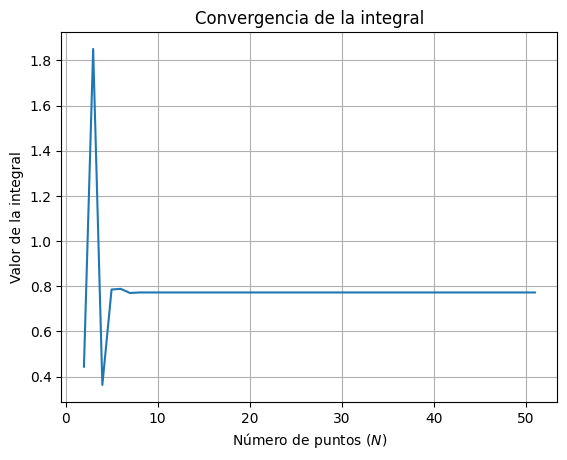

In [39]:
valores_N = np.arange(N_min, N_max + 1)
#Se calcula la cantidad de valores de N y resultados de la integral.
cantidad_n = N_max - N_min + 1
#Se crea un arreglo de resultados.
resultados = np.zeros(cantidad_n)
#El ciclo pasa por cada valor de N.
for i in range(cantidad_n):
    N_actual = valores_N[i]
    #Se calculan los x y w.
    x, w = gaussxw(N_actual)
    #Se escalan los x y w al rango solicitado.
    x_scaled, w_scaled = gaussxwab(0.0, np.pi, x, w)
    #Se calcula el valor de la integral para cada N.
    resultados[i] = np.sum(w_scaled * func(x_scaled))

#Se grafica el valor de la integral en función de N.
plt.plot(valores_N, resultados)

plt.title('Convergencia de la integral')
plt.xlabel('Número de puntos ($N$)')
plt.ylabel('Valor de la integral')
plt.grid(True)
plt.show()